In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

In [4]:
df = pd.read_csv('../data/raw/train.csv')

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Fare']
df_model = df[features + ['Survived']].copy()

df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1})
df_model['Age'] = df_model['Age'].fillna(df_model['Age'].median())
df_model.dropna(inplace=True)

X = df_model[features]
y = df_model['Survived']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[444.,268.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.62,0.38]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,2.697e-06
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Pclass','Sex','Age','SibSp','Fare']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 5)","[[ 2.54, 0.14,29.69, 0.6 ,22.63], [ 1.99, 0.68,28.39, 0.48,49.07]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 5)","[[ 0.54, 0.12, 149.89, 1.88,1045.05], [ 0.73, 0.22, 199.51, 0.56,4998.05]]"


In [7]:
print("Class priors:", gnb.class_prior_)

print("Feature means per class:\n", gnb.theta_)

Class priors: [0.62359551 0.37640449]
Feature means per class:
 [[ 2.53603604  0.14414414 29.69481982  0.59684685 22.63487072]
 [ 1.98880597  0.67537313 28.39119403  0.48134328 49.07293284]]


In [8]:
y_pred = gnb.predict(X_test)

accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

cm = metrics.confusion_matrix(y_test, y_pred)
print(cm)

print(metrics.classification_report(y_test, y_pred,
      target_names=['Did not survive', 'Survived']))

Accuracy: 0.7654
[[84 21]
 [21 53]]
                 precision    recall  f1-score   support

Did not survive       0.80      0.80      0.80       105
       Survived       0.72      0.72      0.72        74

       accuracy                           0.77       179
      macro avg       0.76      0.76      0.76       179
   weighted avg       0.77      0.77      0.77       179



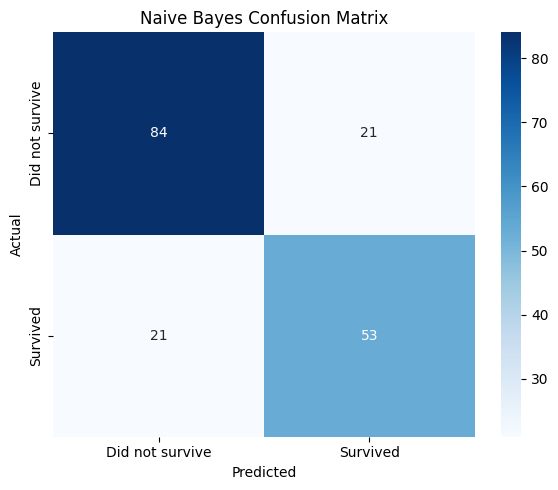

In [9]:
# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.tight_layout()
plt.savefig('../visuals/nb_confusion_matrix.png', dpi=150)
plt.show()

In [10]:
y_prob = gnb.predict_proba(X_test)
print(y_prob[:5])


[[0.95246241 0.04753759]
 [0.89596231 0.10403769]
 [0.94058549 0.05941451]
 [0.09424456 0.90575544]
 [0.27139478 0.72860522]]


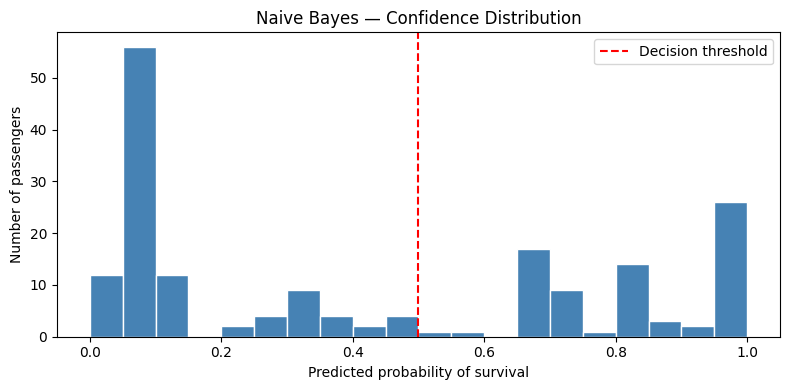

In [11]:
# Visualize the confidence distribution
plt.figure(figsize=(8, 4))
plt.hist(y_prob[:, 1], bins=20, color='steelblue', edgecolor='white')
plt.axvline(0.5, color='red', linestyle='--', label='Decision threshold')
plt.xlabel('Predicted probability of survival')
plt.ylabel('Number of passengers')
plt.title('Naive Bayes — Confidence Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/nb_probability_distribution.png', dpi=150)
plt.show()

In [12]:
feature_names = ['Pclass', 'Sex', 'Age', 'SibSp', 'Fare']

print("=== Class Priors ===")
for i, cls in enumerate(['Did not survive', 'Survived']):
    print(f"  P({cls}) = {gnb.class_prior_[i]:.3f}")

print("\n=== Feature Means per Class ===")
means_df = pd.DataFrame(
    gnb.theta_,
    columns=feature_names,
    index=['Did not survive', 'Survived']
)
print(means_df.round(3))

=== Class Priors ===
  P(Did not survive) = 0.624
  P(Survived) = 0.376

=== Feature Means per Class ===
                 Pclass    Sex     Age  SibSp    Fare
Did not survive   2.536  0.144  29.695  0.597  22.635
Survived          1.989  0.675  28.391  0.481  49.073
